# 08 — Modèle à agents : la bulle de filtres vue d'en bas

Les notebooks précédents travaillent sur des grandeurs agrégées. Celui-ci descend à
l'échelle de l'individu, avec un modèle à agents sur un **compas politique** à deux
axes — économique et sociétal — plutôt que sur le spin binaire d'Ising. C'est une
réponse à l'une des limites que le fil de travail identifiait lui-même : une pensée
réduite à $\pm 1$ ne peut pas représenter la modération.

Le modèle transpose les trois règles des *Boids* de Reynolds en forces sociales :
séparation → distinction, alignement → conformisme, cohésion → besoin
d'appartenance. Il ajoute quatre médias fixes, une contagion de fausse information,
des vérificateurs, et surtout un **seuil de bulle** : la distance d'opinion au-delà
de laquelle deux individus ne se rencontrent jamais.

Ce seuil est le paramètre que l'algorithme de recommandation contrôle. Tout
l'intérêt du notebook est de mesurer ce que l'IDE en dit.

## Ce qui a été corrigé du prototype d'origine

Le prototype `pygame` du fil est conservé tel quel sous `legacy/`. Quatre points
l'empêchaient de produire des résultats exploitables :

1. **Pas de température sociale.** Sans agitation individuelle, le conformisme est
   une force purement contractante : la population s'effondre sur un point unique et
   l'IDE tombe à zéro quels que soient les autres réglages. Le modèle ne pouvait
   représenter ni le débat fluide, ni l'effet du bruit thermique que la note propose
   précisément d'injecter.
2. **Contamination par téléportation.** `infecter()` plaçait instantanément
   l'individu dans un coin du compas, supprimant toute dynamique ultérieure. La
   radicalisation est désormais progressive.
3. **Vérification infaillible.** Tout individu passant à portée d'un fact-checker
   était soigné avec certitude — hypothèse que la littérature sur l'hystérésis des
   croyances contredit précisément. L'efficacité est devenue probabiliste.
4. **Bords absorbants.** Le rabattement par troncature accumulait les individus
   agités dans les coins, faisant chuter l'IDE à haute température pour une raison
   purement numérique. Les bords sont maintenant réfléchissants.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.abm import SocietyModel, SocietyParameters
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()

STEPS = 150

def simulate(bubble_threshold: float, seed: int = 4) -> tuple[SocietyModel, list]:
    parameters = SocietyParameters(
        population=250,
        bubble_threshold=bubble_threshold,
        social_temperature=0.03,
        fake_news_probability=0.02,
    )
    model = SocietyModel(parameters, seed=seed)
    history = model.run(STEPS, inject_at={20: 3})
    return model, history

narrow_model, narrow_history = simulate(0.10)
wide_model, wide_history = simulate(0.80)

for label, history in [("bulle étroite (0,10)", narrow_history), ("société ouverte (0,80)", wide_history)]:
    final = history[-1]
    print(f"{label:24s} IDE={final.exposure_index:.3f}  polarisation={final.polarisation:5.1f}%  "
          f"gelés={final.frozen_fraction:.0%}  contaminés={final.infected_fraction:.0%}")

bulle étroite (0,10)     IDE=0.216  polarisation= 34.0%  gelés=71%  contaminés=3%
société ouverte (0,80)   IDE=0.899  polarisation=  9.7%  gelés=0%  contaminés=83%


## Deux métriques qui ne disent pas la même chose

La **polarisation** — distance moyenne à la modération — décrit l'état macroscopique
de la société. L'**IDE moyen** décrit ce que chaque individu *voit*.

L'écart entre les deux est instructif, et c'est l'argument central du projet : une
société peut être fortement polarisée tout en offrant un IDE élevé (quatre blocs qui
s'affrontent en se voyant), ou faiblement polarisée avec un IDE effondré (tout le
monde d'accord). Le régulateur doit mesurer la **seconde** — c'est celle qui décrit
l'autonomie cognitive réelle, et c'est celle que l'algorithme détermine.

In [2]:
thresholds = (0.05, 0.1, 0.2, 0.4, 0.8, 1.6)
sweep = []
for threshold in thresholds:
    _, history = simulate(threshold)
    sweep.append((threshold, history[-1].exposure_index, history[-1].polarisation))

for threshold, index, polarisation in sweep:
    print(f"seuil={threshold:4.2f}  IDE={index:.3f}  polarisation={polarisation:5.1f}%")

seuil=0.05  IDE=0.302  polarisation= 35.5%
seuil=0.10  IDE=0.216  polarisation= 34.0%
seuil=0.20  IDE=0.402  polarisation= 22.2%
seuil=0.40  IDE=0.890  polarisation=  9.6%
seuil=0.80  IDE=0.899  polarisation=  9.7%
seuil=1.60  IDE=0.899  polarisation=  9.7%


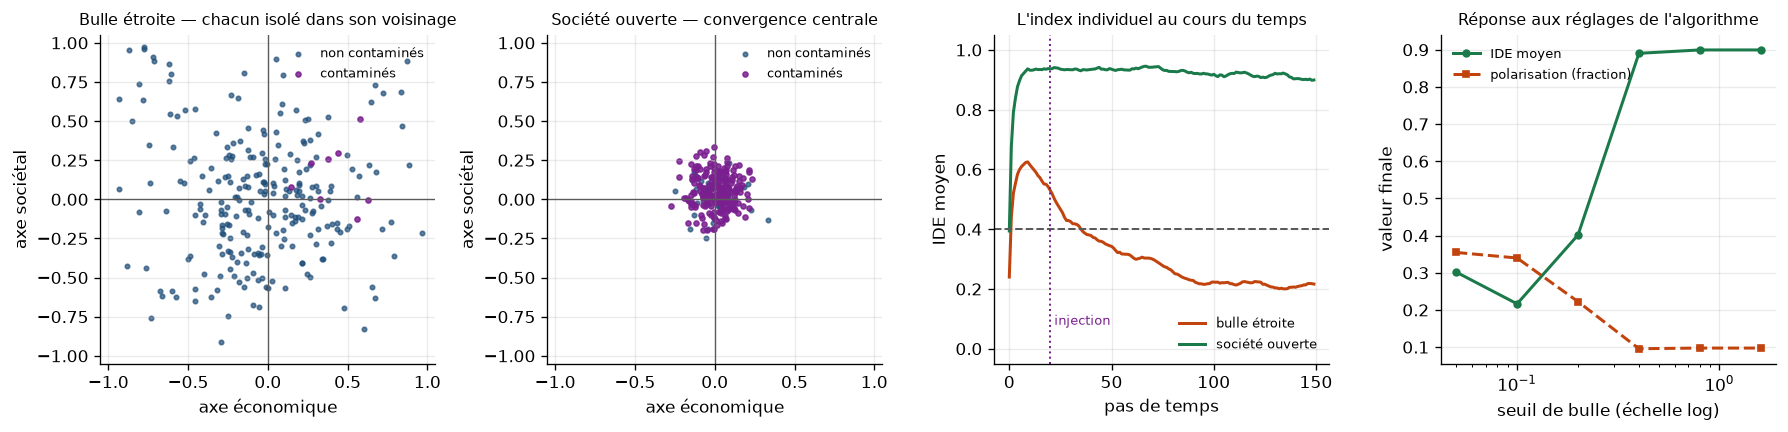

In [3]:
figure, axes = plt.subplots(1, 4, figsize=(15, 3.7))
narrow_map, wide_map, timeseries, response = axes

for panel, model, title in [
    (narrow_map, narrow_model, "Bulle étroite — chacun isolé dans son voisinage"),
    (wide_map, wide_model, "Société ouverte — convergence centrale"),
]:
    cloud = model.opinion_cloud()
    infected = np.array([citizen.infected for citizen in model.citizens])
    panel.scatter(cloud[~infected, 0], cloud[~infected, 1], s=7,
                  color=PALETTE["order"], alpha=0.7, label="non contaminés")
    panel.scatter(cloud[infected, 0], cloud[infected, 1], s=9,
                  color=PALETTE["field"], alpha=0.85, label="contaminés")
    panel.axhline(0.0, color=PALETTE["neutral"], linewidth=0.8)
    panel.axvline(0.0, color=PALETTE["neutral"], linewidth=0.8)
    panel.set_xlim(-1.05, 1.05)
    panel.set_ylim(-1.05, 1.05)
    panel.set_xlabel("axe économique")
    panel.set_ylabel("axe sociétal")
    panel.set_title(title, fontsize=9.5)
    panel.legend(fontsize=7.5, loc="upper right")

for history, colour, label in [
    (narrow_history, PALETTE["disorder"], "bulle étroite"),
    (wide_history, PALETTE["remedy"], "société ouverte"),
]:
    timeseries.plot([record.exposure_index for record in history], color=colour, label=label)

timeseries.axhline(0.4, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
timeseries.axvline(20, color=PALETTE["field"], linestyle=":", linewidth=1.2)
timeseries.text(22, 0.08, "injection", color=PALETTE["field"], fontsize=8)
timeseries.set_xlabel("pas de temps")
timeseries.set_ylabel("IDE moyen")
timeseries.set_ylim(-0.05, 1.05)
timeseries.set_title("L'index individuel au cours du temps", fontsize=9.5)
timeseries.legend(fontsize=8)

widths = [item[0] for item in sweep]
response.plot(widths, [item[1] for item in sweep], "o-", color=PALETTE["remedy"],
              markersize=4, label="IDE moyen")
response.plot(widths, [item[2] / 100.0 for item in sweep], "s--", color=PALETTE["disorder"],
              markersize=4, label="polarisation (fraction)")
response.set_xscale("log")
response.set_xlabel("seuil de bulle (échelle log)")
response.set_ylabel("valeur finale")
response.set_title("Réponse aux réglages de l'algorithme", fontsize=9.5)
response.legend(fontsize=8)

save_figure(figure, "fig08_abm.png")
plt.show()

## Ce que le notebook établit

1. Le seuil de bulle contrôle directement l'IDE : le resserrer effondre l'index et
   fait basculer la quasi-totalité de la population sous le seuil critique. C'est
   exactement le mécanisme que le mémorandum propose de rendre constatable — et il
   est mesurable de l'extérieur, sans accès au code de la plateforme.
2. Le compartimentage **maintient les individus dispersés et loin du centre**,
   tandis que la société ouverte converge vers la modération : la cartographie du
   compas rend les deux régimes visibles d'un coup d'œil. À noter que la société
   ouverte paie cette convergence par une contagion totale — tout le monde se parle,
   donc tout le monde attrape la fausse information. Ouvrir les bulles n'est pas une
   politique sanitaire de l'information, c'est une politique d'exposition.
3. Polarisation et IDE se dissocient : mesurer l'une ne dispense pas de mesurer
   l'autre, et c'est l'IDE qui capte l'enfermement.
4. Le modèle est **reproductible à la graine** : deux exécutions identiques donnent
   des historiques identiques, ce qui est la condition minimale pour qu'un chiffre du
   dépôt soit citable.